Extracting C:\Users\86185\Desktop\专业课\大三上\人工智能大数据\实验\实验八\MNIST_data\train-images-idx3-ubyte.gz
Extracting C:\Users\86185\Desktop\专业课\大三上\人工智能大数据\实验\实验八\MNIST_data\train-labels-idx1-ubyte.gz
Extracting C:\Users\86185\Desktop\专业课\大三上\人工智能大数据\实验\实验八\MNIST_data\t10k-images-idx3-ubyte.gz
Extracting C:\Users\86185\Desktop\专业课\大三上\人工智能大数据\实验\实验八\MNIST_data\t10k-labels-idx1-ubyte.gz
请输入需要训练的次数：5000
第 1000次训练 损失值: 1.104776 训练准确率:67.188%
第 2000次训练 损失值: 0.352333 训练准确率:87.500%
第 3000次训练 损失值: 0.254293 训练准确率:95.312%
第 4000次训练 损失值: 0.314322 训练准确率:90.625%
第 5000次训练 损失值: 0.139557 训练准确率:96.875%
测试准确率:92.220%
请输入想要查看的图像编号：8


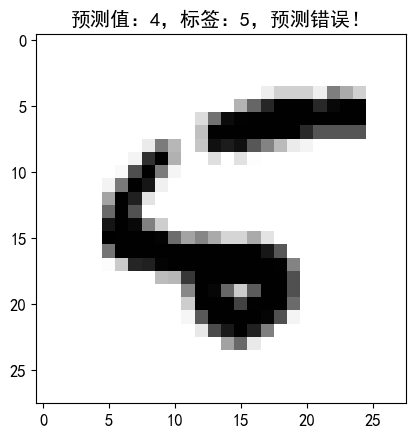

INFO:tensorflow:Restoring parameters from ./mnist_models/model.ckpt-5000
输入任意数字母继续，如果要退出查看，请直接回车。
5
请输入想要查看的图像编号：111


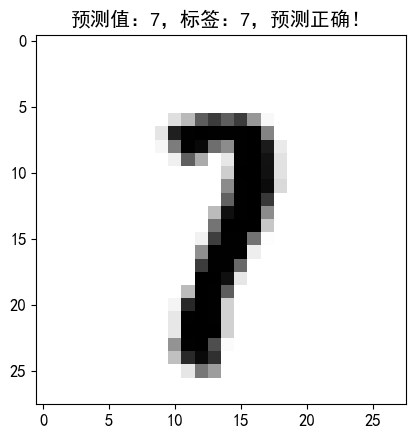

INFO:tensorflow:Restoring parameters from ./mnist_models/model.ckpt-5000
输入任意数字母继续，如果要退出查看，请直接回车。


In [ ]:
from tensorflow.examples.tutorials.mnist import input_data
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from typing import Any,Callable,Dict, Mapping, Optional, Sequence, Tuple
from typing_extensions import OrderedDict
import warnings
warnings.filterwarnings('ignore')
mnist=input_data.read_data_sets("C:\\Users\\86185\\Desktop\\专业课\\大三上\\人工智能大数据\\实验\\实验八\\MNIST_data",one_hot=True)
in_x = tf.placeholder(tf.float32, [None, 784], name='x-input')
in_y = tf.placeholder(tf.float32, [None, 10], name='y-input')
def init_weights(shape):
    return tf.Variable(tf.random_normal(shape, stddev=0.01))
h1 = init_weights([784, 16])
h2 = init_weights([16, 16])
out = init_weights([16, 10])
def model(X, h1, h2, out):
    h =tf.nn.relu(tf.matmul(X, h1))
    h2 = tf.nn.relu(tf.matmul(h, h2))
    return tf.matmul(h2,out)
mod = model(in_x,h1,h2,out)
cost =tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=mod, labels=in_y))
train_op =tf.train.RMSPropOptimizer(0.001, 0.9).minimize(cost)
predict_acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(mod, 1),tf.argmax(in_y, 1)),tf.float32))
train_num =1000
figure_num = 64
saver =tf.train.Saver()
sess=tf.Session()
sess.run(tf.global_variables_initializer())
train_num =int(input('请输入需要训练的次数：'))
for step in range(1,train_num+1):
    batch_x, batch_y =mnist.train.next_batch(figure_num)
    sess.run(train_op, feed_dict={in_x: batch_x, in_y: batch_y})
    if step % 1000 == 0:
        loss, acc =sess.run([cost, predict_acc], feed_dict={in_x: batch_x,in_y: batch_y})
        print("第%5d次训练"%step, "损失值: {:.6f}".format(loss), "训练准确率:{:.3f}%".format(acc*100))
    saver.save(sess, './mnist_models/model.ckpt',global_step=step)
print("测试准确率:{:0.3f}%".format(sess.run(predict_acc, feed_dict={in_x: mnist.test.images, in_y:mnist.test.labels})*100))

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.rc("font",family="SimHei",size="12")
def display_compare(num):
    x_train=mnist.test.images[num,:].reshape(1,784)
    y_train = mnist.test.labels[num, :]
    np.set_printoptions(precision=1)
    np.set_printoptions(suppress=True)
    label =y_train.argmax()
    prediction = sess.run(mod, feed_dict={in_x: x_train}).argmax()
    if(prediction==label):
        plt.title('预测值：%d，标签：%s，预测正确！' %(prediction, label))
    else:
        plt.title('预测值：%d，标签：%s，预测错误！' %(prediction, label))
    plt.imshow(x_train.reshape([28, 28]), cmap=plt.get_cmap('gray_r'))
    plt.savefig(f"test08_{num}.png")
    plt.show()
    module_file = tf.train.latest_checkpoint('./mnist_models/')
    saver.restore(sess, module_file)
while True:
    n =int(input('请输入想要查看的图像编号：'))
    display_compare(n)
    print('输入任意数字母继续，如果要退出查看，请直接回车。')
    flag =bool(input())
    if flag==False:
        break